# 1. Cleaning

In [1]:
# Load disaster dataset
import pandas as pd
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns



df_disaster = pd.read_csv("data/natural_disaster_data_reworked.csv")

In [2]:
df_disaster.head()

,AGRN,Start date,End date,Duration,State,Disaster Types
0,837,04/01/2019,NaN,NaN,VIC,Bushfire
1,839,10/01/2019,NaN,NaN,WA,Bushfire
2,840,25/01/2019,NaN,NaN,QLD,Flood
3,843,11/02/2019,NaN,NaN,NSW,Bushfire
4,845,11/01/2019,NaN,NaN,NSW,"Flood, Storm"


In [3]:
print(df_disaster.dtypes)

AGRN                int64
Start date         object
End date           object
Duration          float64
State              object
Disaster Types     object
dtype: object


In [4]:
print(df_disaster.shape)

(350, 6)


In [5]:
# missing values
print(df_disaster.isnull().sum())

AGRN                0
Start date         18
End date          195
Duration          195
State               0
Disaster Types      0
dtype: int64


In [6]:
# Convert Start date and End date to datetime

df_disaster['Start date'] = pd.to_datetime(
    df_disaster['Start date'],
    format="%d/%m/%Y",
    errors='coerce'
)

df_disaster['End date'] = pd.to_datetime(
    df_disaster['End date'],
    format="%d/%m/%Y",
    errors='coerce'
)


In [7]:
# Check for missing values after conversion
print("Start date missing:", df_disaster['Start date'].isna().sum())
print("End date missing:", df_disaster['End date'].isna().sum())

Start date missing: 18
End date missing: 195


In [8]:
df_disaster.head()

,AGRN,Start date,End date,Duration,State,Disaster Types
0,837,2019-01-04,NaT,NaN,VIC,Bushfire
1,839,2019-01-10,NaT,NaN,WA,Bushfire
2,840,2019-01-25,NaT,NaN,QLD,Flood
3,843,2019-02-11,NaT,NaN,NSW,Bushfire
4,845,2019-01-11,NaT,NaN,NSW,"Flood, Storm"


In [9]:
# Remove trailing commas, double commas, and trim whitespace
df_disaster['Disaster Types'] = (
    df_disaster['Disaster Types']
    .astype(str)
    .str.replace(r',$', '', regex=True)     # Remove trailing comma
    .str.replace(r',\s*,', ',', regex=True) # Remove double commas
    .str.strip()
)

# Normalize spacing around commas ("Flood,Storm" → "Flood, Storm")
df_disaster['Disaster Types'] = (
    df_disaster['Disaster Types']
    .str.replace(r'\s*,\s*', ', ', regex=True)
)

# Standardize capitalization (First letter uppercase)
df_disaster['Disaster Types'] = (
    df_disaster['Disaster Types']
    .str.title()   # Bushfire → Bushfire | flood → Flood | FLOOD → Flood
)

# Create a clean list of disaster types
df_disaster['Disaster_List'] = df_disaster['Disaster Types'].str.split(r',\s*')

# Show preview
df_disaster[['AGRN', 'Disaster Types', 'Disaster_List']].head(10)

,AGRN,Disaster Types,Disaster_List
0,837,Bushfire,[Bushfire]
1,839,Bushfire,[Bushfire]
2,840,Flood,[Flood]
3,843,Bushfire,[Bushfire]
4,845,"Flood, Storm","[Flood, Storm]"
5,846,Bushfire,[Bushfire]
6,848,"Storm, Flood, Cyclone","[Storm, Flood, Cyclone]"
7,849,"Flood, Cyclone","[Flood, Cyclone]"
8,850,Cyclone,[Cyclone]
9,852,Bushfire,[Bushfire]


In [10]:
df_disaster['Disaster_List'].explode().value_counts()

Disaster_List
Storm         195
Flood         166
Bushfire       98
Cyclone        21
Rainfall       12
Tornado         4
Earthquack      3
Landslide       1
Name: count, dtype: int64

In [11]:
# Hazards allowed to be single-day when dates missing
single_day_hazards = ["Storm", "Rainfall", "Tornado", "Earthquake", "Earthquack", "Landslide"]

# Hazards requiring complete date ranges
multi_day_hazards = ["Flood", "Bushfire", "Cyclone"]

In [12]:
# For hazards that can be single-day events
mask_single = df_disaster['Disaster_List'].apply(
    lambda lst: any(h in lst for h in single_day_hazards)
)

# Fill missing end dates with start date
df_disaster.loc[mask_single & df_disaster['End date'].isna(), 'End date'] = \
    df_disaster.loc[mask_single & df_disaster['End date'].isna(), 'Start date']

# Fill missing start dates with end date
df_disaster.loc[mask_single & df_disaster['Start date'].isna(), 'Start date'] = \
    df_disaster.loc[mask_single & df_disaster['Start date'].isna(), 'End date']

In [13]:
# For hazards that require multi-day events
mask_multi = df_disaster['Disaster_List'].apply(
    lambda lst: any(h in lst for h in multi_day_hazards)
)

# Remove rows with missing start/end dates
df_disaster = df_disaster[
    ~(mask_multi & (df_disaster['Start date'].isna() | df_disaster['End date'].isna()))
    
].copy()

# Calculate Duration_days
df_disaster['Duration_days'] = (
    (df_disaster['End date'] - df_disaster['Start date']).dt.days + 1)

df_disaster = df_disaster.sort_values("Start date").reset_index(drop=True)

df_disaster.head()

,AGRN,Start date,End date,Duration,State,Disaster Types,Disaster_List,Duration_days
0,845,2019-01-11,2019-01-11,NaN,NSW,"Flood, Storm","[Flood, Storm]",1.0
1,856,2019-01-22,2019-01-23,1.0,NSW,Storm,[Storm],2.0
2,859,2019-01-30,2019-01-30,NaN,VIC,"Storm, Bushfire","[Storm, Bushfire]",1.0
3,857,2019-02-05,2019-02-05,NaN,NSW,"Storm, Flood","[Storm, Flood]",1.0
4,861,2019-02-08,2019-02-08,NaN,NSW,Storm,[Storm],1.0


In [14]:
# missing values
print(df_disaster.isnull().sum())

AGRN                0
Start date          4
End date            4
Duration          125
State               0
Disaster Types      0
Disaster_List       0
Duration_days       4
dtype: int64


In [15]:
# show missing duration rows
print(df_disaster[df_disaster['Duration_days'].isnull()])

     AGRN Start date End date  Duration State Disaster Types Disaster_List  \
276   914        NaT      NaT       NaN   TAS          Storm       [Storm]   
277   940        NaT      NaT       NaN    SA          Storm       [Storm]   
278  1028        NaT      NaT       NaN   QLD          Storm       [Storm]   
279  1043        NaT      NaT       NaN    NT          Storm       [Storm]   

     Duration_days  
276            NaN  
277            NaN  
278            NaN  
279            NaN  


In [16]:
# drop rows with missing Duration_days
df_disaster = df_disaster.dropna(subset=['Duration_days']).copy()

In [17]:
df_disaster = df_disaster.rename(columns={
    "AGRN": "agrn",
    "Start date": "start_date",
    "End date": "end_date",
    "Duration": "duration_raw",
    "State": "state",
    "Disaster Types": "disaster_types",
    "Disaster_List": "disaster_list",
    "Duration_days": "duration_days"
})

df_disaster.head()

,agrn,start_date,end_date,duration_raw,state,disaster_types,disaster_list,duration_days
0,845,2019-01-11,2019-01-11,NaN,NSW,"Flood, Storm","[Flood, Storm]",1.0
1,856,2019-01-22,2019-01-23,1.0,NSW,Storm,[Storm],2.0
2,859,2019-01-30,2019-01-30,NaN,VIC,"Storm, Bushfire","[Storm, Bushfire]",1.0
3,857,2019-02-05,2019-02-05,NaN,NSW,"Storm, Flood","[Storm, Flood]",1.0
4,861,2019-02-08,2019-02-08,NaN,NSW,Storm,[Storm],1.0


In [18]:
# remove duration_raw, distaster_types
df_disaster = df_disaster.drop(columns=['duration_raw', 'disaster_types'])

# change disaster_list to disaster_types
df_disaster = df_disaster.rename(columns={'disaster_list': 'disaster_types'})

In [19]:
# missing values
print(df_disaster.isnull().sum())

agrn              0
start_date        0
end_date          0
state             0
disaster_types    0
duration_days     0
dtype: int64


In [20]:
desired_order = [
    "agrn",
    "state",
    "start_date",
    "end_date",
    "duration_days",
    "disaster_types"
]

df_disaster = df_disaster[desired_order]
df_disaster.head()

,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,"[Flood, Storm]"
1,856,NSW,2019-01-22,2019-01-23,2.0,[Storm]
2,859,VIC,2019-01-30,2019-01-30,1.0,"[Storm, Bushfire]"
3,857,NSW,2019-02-05,2019-02-05,1.0,"[Storm, Flood]"
4,861,NSW,2019-02-08,2019-02-08,1.0,[Storm]


In [21]:
df_disaster.head()

,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,"[Flood, Storm]"
1,856,NSW,2019-01-22,2019-01-23,2.0,[Storm]
2,859,VIC,2019-01-30,2019-01-30,1.0,"[Storm, Bushfire]"
3,857,NSW,2019-02-05,2019-02-05,1.0,"[Storm, Flood]"
4,861,NSW,2019-02-08,2019-02-08,1.0,[Storm]


In [22]:
# shape
print("Final dataset shape:", df_disaster.shape)

Final dataset shape: (276, 6)


In [23]:
# Fix spelling: Earthqack → Earthquake
df_disaster["disaster_types"] = df_disaster["disaster_types"].apply(
    lambda x: tuple("Earthquake" if d.lower() == "earthquack" else d for d in x)
)

# Display unique disasters
unique_disasters = pd.Series(
    sorted({d for types in df_disaster["disaster_types"] for d in types}),
    name="Disaster Types"
)
print(unique_disasters)

0      Bushfire
1       Cyclone
2    Earthquake
3         Flood
4     Landslide
5      Rainfall
6         Storm
7       Tornado
Name: Disaster Types, dtype: object


In [24]:
# Fix spelling first (if "Earthquack" appears)
df_disaster['disaster_types'] = df_disaster['disaster_types'].apply(
    lambda lst: ["Earthquake" if x in ["Earthquake", "Earthquack"] else x for x in lst]
)

# Identify earthquake events
mask_eq = df_disaster['disaster_types'].apply(lambda lst: "Earthquake" in lst)

# Fix end_date = start_date for earthquakes
df_disaster.loc[mask_eq, 'end_date'] = df_disaster.loc[mask_eq, 'start_date']

# Fix duration to 1 day
df_disaster.loc[mask_eq, 'duration_days'] = 1

In [25]:
# find missing values
print(df_disaster.isnull().sum())

agrn              0
state             0
start_date        0
end_date          0
duration_days     0
disaster_types    0
dtype: int64


In [26]:
df_disaster.head()

,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,"[Flood, Storm]"
1,856,NSW,2019-01-22,2019-01-23,2.0,[Storm]
2,859,VIC,2019-01-30,2019-01-30,1.0,"[Storm, Bushfire]"
3,857,NSW,2019-02-05,2019-02-05,1.0,"[Storm, Flood]"
4,861,NSW,2019-02-08,2019-02-08,1.0,[Storm]


In [27]:
# sort by start date    
df_disaster = df_disaster.sort_values("start_date").reset_index(drop=True)
df_disaster.head()


,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,"[Flood, Storm]"
1,856,NSW,2019-01-22,2019-01-23,2.0,[Storm]
2,859,VIC,2019-01-30,2019-01-30,1.0,"[Storm, Bushfire]"
3,857,NSW,2019-02-05,2019-02-05,1.0,"[Storm, Flood]"
4,861,NSW,2019-02-08,2019-02-08,1.0,[Storm]


In [28]:
# save the cleaned DataFrame to a new CSV file
df_disaster.to_csv("data/natural_disaster_data_cleaned_reworked.csv", index=False)
df_disaster.head()


,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,"[Flood, Storm]"
1,856,NSW,2019-01-22,2019-01-23,2.0,[Storm]
2,859,VIC,2019-01-30,2019-01-30,1.0,"[Storm, Bushfire]"
3,857,NSW,2019-02-05,2019-02-05,1.0,"[Storm, Flood]"
4,861,NSW,2019-02-08,2019-02-08,1.0,[Storm]


# 2. EDA

In [29]:
# load the cleaned DataFrame
df_disaster_clean = pd.read_csv("data/natural_disaster_data_cleaned_reworked.csv")
df_disaster_clean.head()


,agrn,state,start_date,end_date,duration_days,disaster_types
0,845,NSW,2019-01-11,2019-01-11,1.0,"['Flood', 'Storm']"
1,856,NSW,2019-01-22,2019-01-23,2.0,['Storm']
2,859,VIC,2019-01-30,2019-01-30,1.0,"['Storm', 'Bushfire']"
3,857,NSW,2019-02-05,2019-02-05,1.0,"['Storm', 'Flood']"
4,861,NSW,2019-02-08,2019-02-08,1.0,['Storm']


In [30]:
# Average duration per disaster type (days)
avg_duration = (
    df_disaster_clean.explode("disaster_types").groupby("disaster_types")["duration_days"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_duration)

disaster_types
['Flood', 'Cyclone', 'Rainfall']    33.000000
['Bushfire']                        20.358491
['Storm', 'Rainfall']               15.000000
['Flood', 'Cyclone']                13.400000
['Flood', 'Rainfall']               10.714286
['Flood']                            8.333333
['Cyclone']                          8.166667
['Storm', 'Flood']                   7.063636
['Storm', 'Flood', 'Cyclone']        6.750000
['Storm']                            2.215385
['Earthquake']                       1.000000
['Flood', 'Storm']                   1.000000
['Storm', 'Bushfire']                1.000000
['Storm', 'Flood', 'Landslide']      1.000000
['Storm', 'Flood', 'Rainfall']       1.000000
['Storm', 'Tornado']                 1.000000
Name: duration_days, dtype: float64


In [31]:
# Ensure disaster_types is converted from string → list
df_disaster_clean['disaster_types'] = df_disaster_clean['disaster_types'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Expand list column into long format
rows = []
for _, row in df_disaster_clean.iterrows():
    for d in row['disaster_types']:
        rows.append({
            "disaster_type": d,
            "duration_days": row["duration_days"]
        })

df_long = pd.DataFrame(rows)

# Compute average duration per disaster type
avg_duration = df_long.groupby("disaster_type")["duration_days"].mean().round(2).sort_values()

print("Average Duration (Days) by Disaster Type:")
print(avg_duration)

Average Duration (Days) by Disaster Type:
disaster_type
Earthquake     1.00
Landslide      1.00
Tornado        1.00
Storm          5.14
Flood          7.62
Cyclone       11.00
Rainfall      12.40
Bushfire      19.65
Name: duration_days, dtype: float64


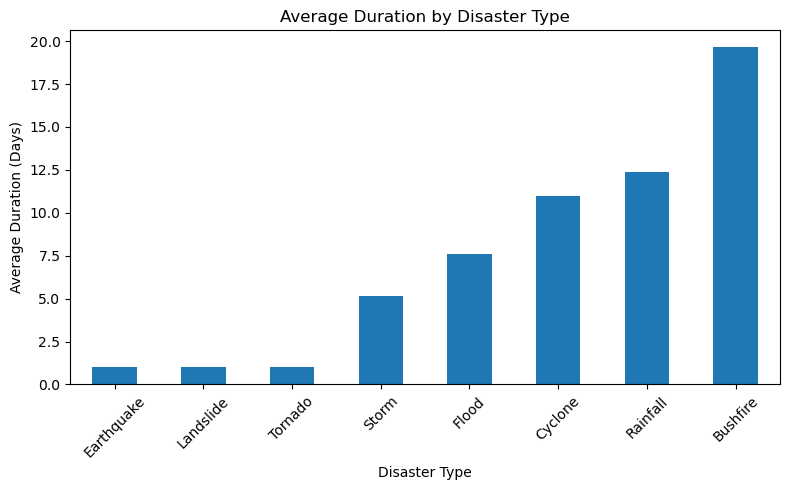

In [32]:
# Plot bar chart
plt.figure(figsize=(8, 5))
avg_duration.plot(kind="bar")
plt.xlabel("Disaster Type")
plt.ylabel("Average Duration (Days)")
plt.title("Average Duration by Disaster Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

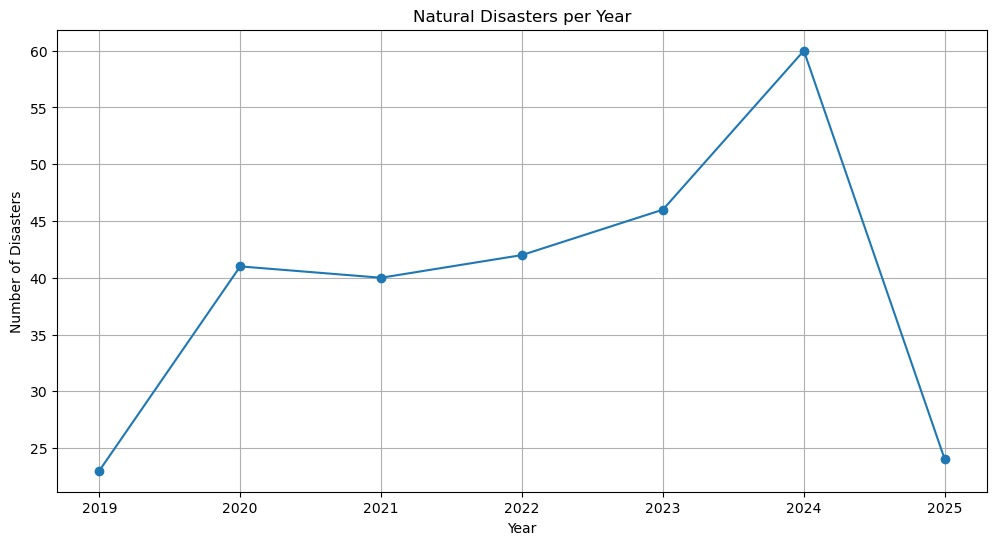

In [33]:
# visual for disaster counts per year
df_disaster_clean['year'] = pd.to_datetime(df_disaster_clean['start_date']).dt.year
disasters_per_year = df_disaster_clean['year'].value_counts().sort_index()      
plt.figure(figsize=(12, 6))
plt.plot(disasters_per_year.index, disasters_per_year.values, marker='o')
plt.title("Natural Disasters per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid()
plt.show()  


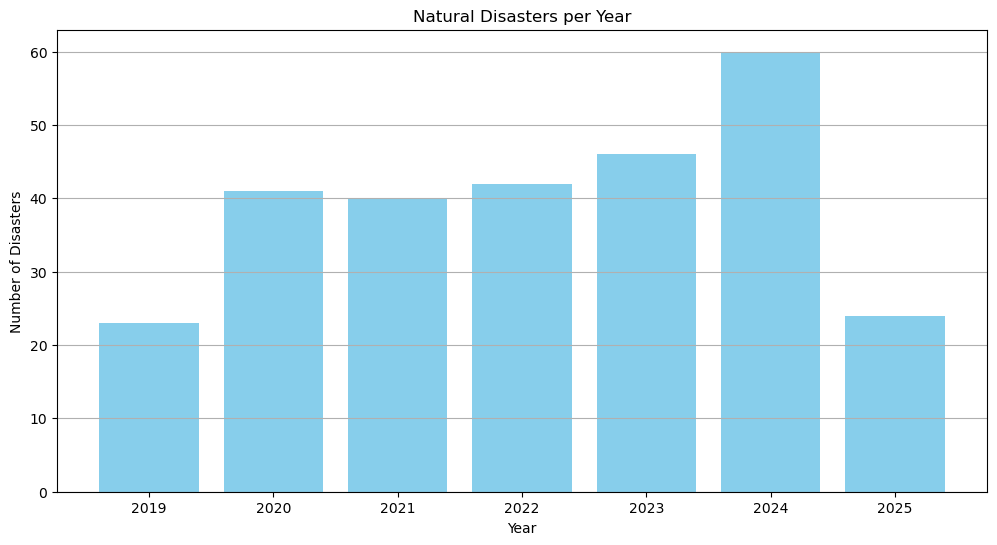

In [34]:
# bar chart of disaster counts per year
df_disaster_clean['year'] = pd.to_datetime(df_disaster_clean['start_date']).dt.year
disasters_per_year = df_disaster_clean['year'].value_counts().sort_index()      
plt.figure(figsize=(12, 6))
plt.bar(disasters_per_year.index, disasters_per_year.values, color='skyblue')
plt.title("Natural Disasters per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(axis='y')
plt.show()

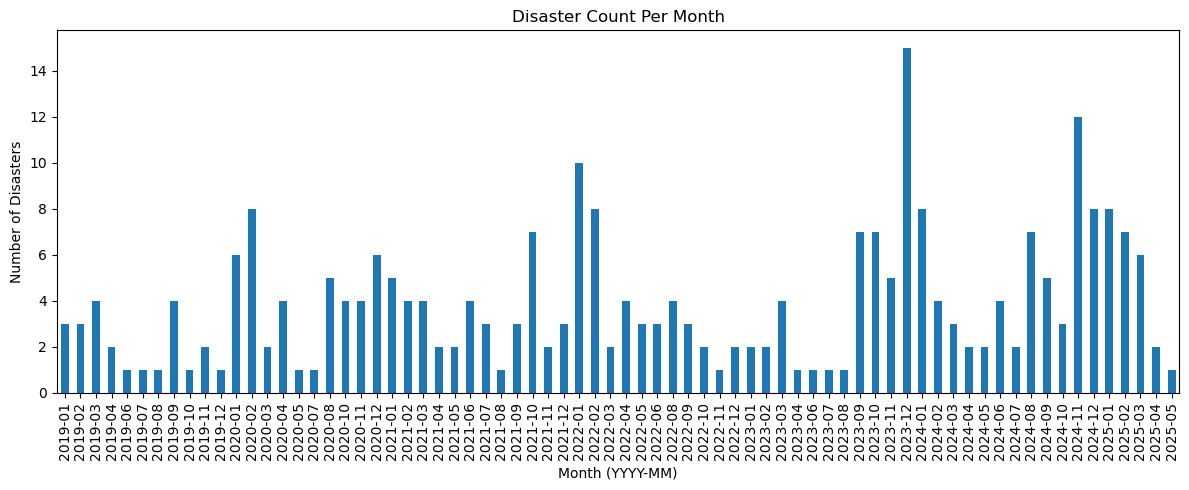

In [35]:
# Convert start_date to datetime if not already
df_disaster_clean['start_date'] = pd.to_datetime(df_disaster_clean['start_date'])

# Create a year-month column (YYYY-MM)
df_disaster_clean['year_month'] = df_disaster_clean['start_date'].dt.to_period('M')

# Count disasters per month
monthly_counts = df_disaster_clean['year_month'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 5))
monthly_counts.plot(kind='bar')

plt.xlabel("Month (YYYY-MM)")
plt.ylabel("Number of Disasters")
plt.title("Disaster Count Per Month")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [36]:
# Which states have the most disasters
state_counts = df_disaster_clean['state'].value_counts()
state_counts

state
NSW    101
QLD     67
VIC     44
WA      44
TAS      7
ACT      5
NT       5
SA       3
Name: count, dtype: int64

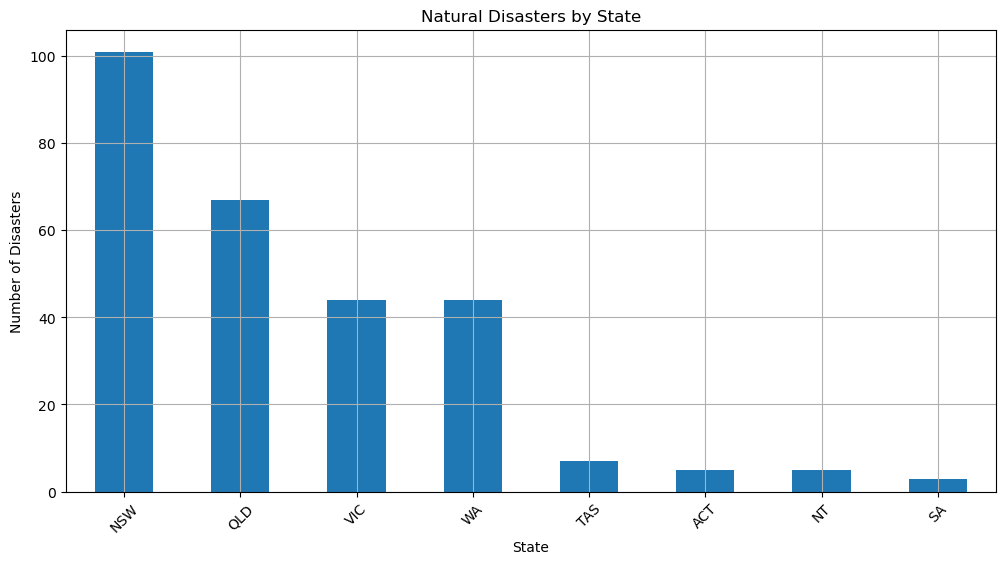

In [37]:
# visual for states with most disasters
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
state_counts.plot(kind='bar')
plt.title("Natural Disasters by State")
plt.xlabel("State")
plt.ylabel("Number of Disasters")
plt.xticks(rotation=45)
plt.grid()
plt.show()


/var/folders/jm/36rrr53s1w388ms7208drrcm0000gn/T/ipykernel_85256/2794563759.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


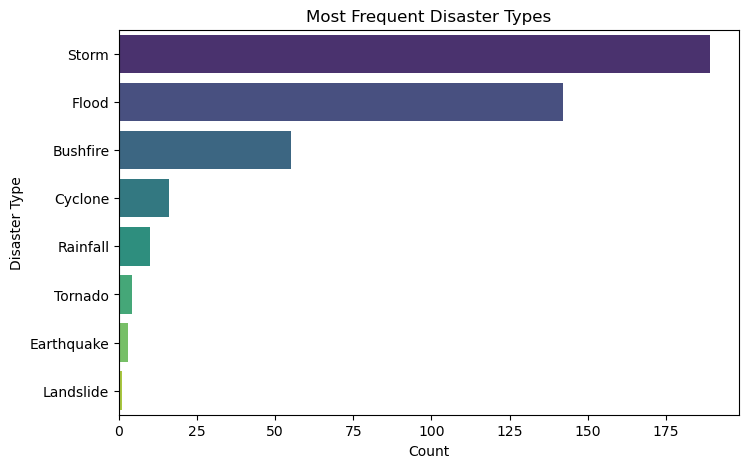

In [38]:
# Visualization: Top disaster types
top_disasters = df_disaster_clean.explode("disaster_types")['disaster_types'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    y=top_disasters.index,
    x=top_disasters.values,
    palette="viridis"
)
plt.title("Most Frequent Disaster Types")
plt.xlabel("Count")
plt.ylabel("Disaster Type")
plt.show()

disaster_type  Bushfire  Cyclone  Earthquake  Flood  Landslide  Rainfall  \
state                                                                      
ACT                   1        0           0      0          0         0   
NSW                  29        1           1     41          0         0   
NT                    1        2           0      4          0         0   
QLD                  20        7           0     33          0         8   
SA                    0        0           0      2          0         0   
TAS                   0        0           0      5          0         0   
VIC                   2        0           2     23          1         0   
WA                    2        6           0     34          0         2   

disaster_type  Storm  Tornado  
state                          
ACT                4        0  
NSW               71        2  
NT                 1        0  
QLD               31        0  
SA                 3        0  
TAS            

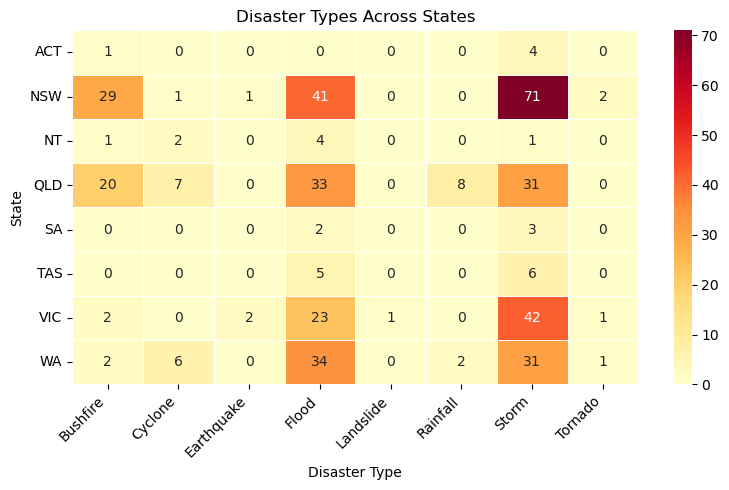

In [39]:
# Heatmap: Disaster types across states
df_dis = df_disaster_clean.copy()

df_dis['disaster_types'] = df_dis['disaster_types'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_long = df_dis.explode('disaster_types')

df_long = df_long.rename(columns={'disaster_types': 'disaster_type'})

heat_data = pd.crosstab(
    df_long['state'],
    df_long['disaster_type']
)

print(heat_data)  # quick check

plt.figure(figsize=(8, 5))
sns.heatmap(
    heat_data,
    annot=True,       # show counts in cells
    fmt='d',          # integer format
    linewidths=0.5,
    cmap='YlOrRd'     # you can change or remove this if you like
)
plt.title("Disaster Types Across States")
plt.xlabel("Disaster Type")
plt.ylabel("State")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Yearly Trend Table:

disaster_type  Bushfire  Cyclone  Earthquake  Flood  Landslide  Rainfall  \
year                                                                       
2019                  7        2           0      9          0         0   
2020                  4        2           0     26          0         0   
2021                  0        3           1     25          0         0   
2022                  2        2           0     32          0         0   
2023                 23        1           0     13          1         0   
2024                 15        3           2     31          0         9   
2025                  4        3           0      6          0         1   

disaster_type  Storm  Tornado  
year                           
2019              16        0  
2020              35        0  
2021              35        2  
2022              32        0  
2023              19        1  
2024              34        1  
2025              18        0  


<Figure size 1200x600 with 0 Axes>

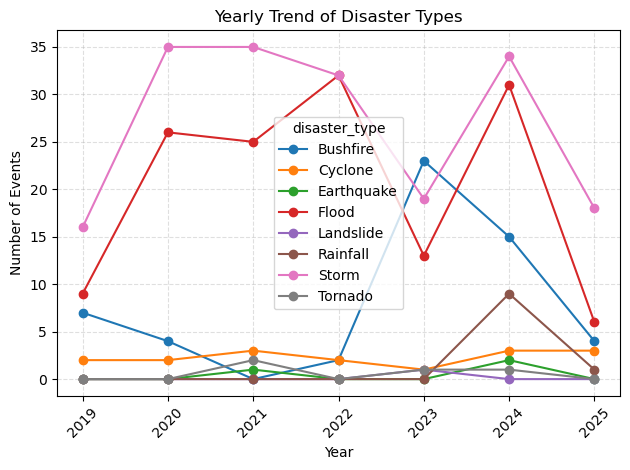

In [40]:
# Yearly trend of disaster types
df = df_disaster_clean.copy()
df['start_date'] = pd.to_datetime(df['start_date'])

df['disaster_types'] = df['disaster_types'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_long = df.explode("disaster_types").rename(columns={"disaster_types": "disaster_type"})

df_long['year'] = df_long['start_date'].dt.year

yearly_trend = df_long.groupby(['year', 'disaster_type']).size().unstack(fill_value=0)

print("\nYearly Trend Table:\n")
print(yearly_trend)

plt.figure(figsize=(12, 6))
yearly_trend.plot(kind='line', marker='o')

plt.title("Yearly Trend of Disaster Types")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.xticks(yearly_trend.index, rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Disaster Frequency by Month:
month_name
January      42
February     36
March        25
April        17
May           9
June         13
July          8
August       19
September    22
October      24
November     26
December     35
Name: count, dtype: int64


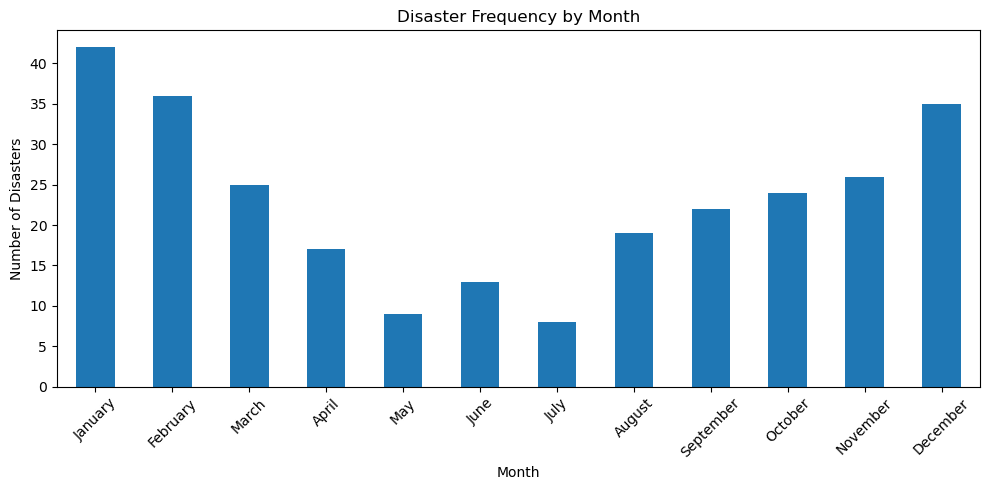

In [41]:
# Copy dataset
df = df_disaster_clean.copy()

# Make sure date column is datetime
df['start_date'] = pd.to_datetime(df['start_date'])

# Extract month name and month number
df['month'] = df['start_date'].dt.month
df['month_name'] = df['start_date'].dt.strftime('%B')

# Count disasters by month (across all years)
month_counts = df['month_name'].value_counts().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])

print("Disaster Frequency by Month:")
print(month_counts)

# Plot
plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar')

plt.title("Disaster Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Disaster Frequency by Season:
season
Summer    113
Autumn     51
Winter     40
Spring     72
Name: count, dtype: int64


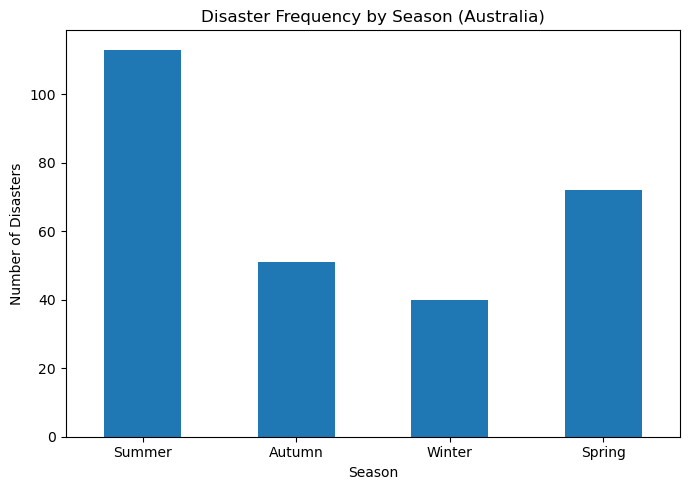

In [42]:
# Ensure date column is datetime
df['start_date'] = pd.to_datetime(df['start_date'])

# Extract month
df['month'] = df['start_date'].dt.month

# Map months to Australian seasons
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:  # 9, 10, 11
        return "Spring"

df['season'] = df['month'].apply(month_to_season)

# Count disasters by season
season_counts = df['season'].value_counts().reindex(["Summer", "Autumn", "Winter", "Spring"])

print("Disaster Frequency by Season:")
print(season_counts)

# Plot
plt.figure(figsize=(7, 5))
season_counts.plot(kind='bar')

plt.title("Disaster Frequency by Season (Australia)")
plt.xlabel("Season")
plt.ylabel("Number of Disasters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()